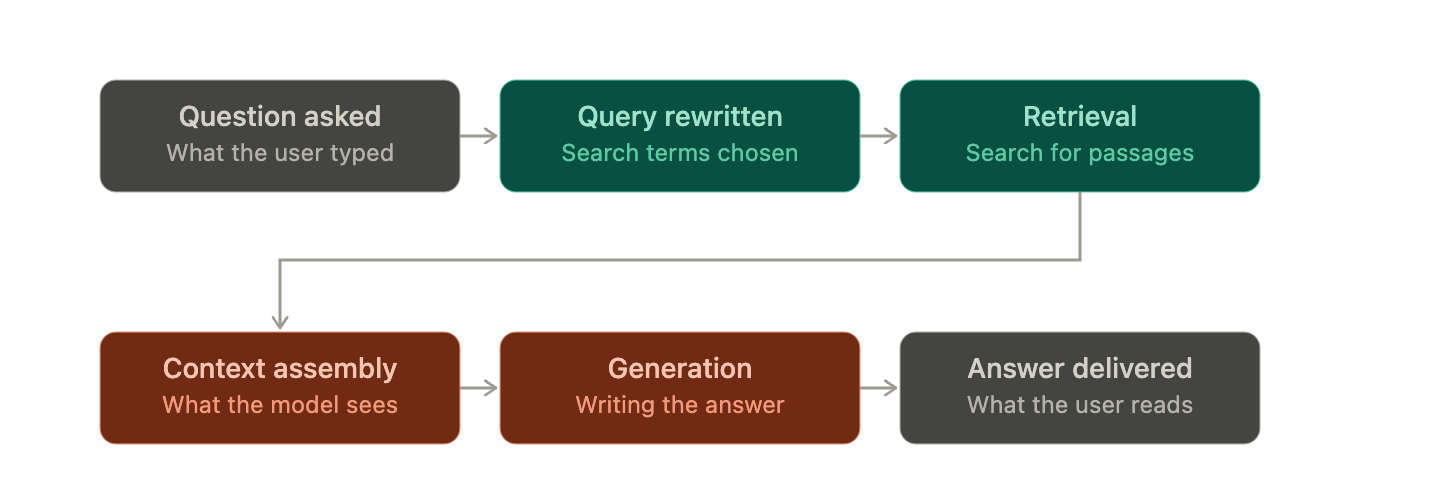

Let's set up the pipeline first, so you can see the chain of handoffs before we walk through each link.Think of every RAG answer as the last statement in a chain of custody. By the time you read the final sentence, the question has passed through several hands — and each handoff is a place where something could be dropped, distorted, or invented. A good evaluator doesn't interrogate the final answer first. They work backward through the chain, checking each handoff's alibi before deciding who's guilty.

Let's run one case throughout: an HR chatbot, and the question *"How many vacation days do new employees get?"*

**Stage 0 — the question as asked**

*In:* the raw text the user typed.
*Out:* itself — but this becomes the "original statement" everything downstream has to stay faithful to.

*What can go wrong:* the question can carry a hidden ambiguity nobody downstream will notice. "New employees" — does that mean first 90 days, first year, hourly or salaried staff? If the handbook actually gives three different answers depending on employee class, and the question never specifies which one, then no later stage can rescue this. The case was unsolvable as stated.

Detective rule: before blaming any witness further down the chain, check whether the question itself could even have one true answer.

**Stage 1 — query rewriting**

*In:* the original question.
*Out:* the query actually used for search — sometimes identical to the question, sometimes expanded or simplified.

*What can go wrong:* the rewrite drops a qualifier. If the system simplifies "vacation days for new employees" down to just "vacation policy," it'll search for the general PTO passage instead of the new-hire-specific clause — the part that mattered most just got erased before the search even ran.

Detective tell: lay the original question next to the query that was actually sent to search. If a meaningful word vanished in the rewrite, you've found a suspect before you even reach the filing cabinet.

**Stage 2 — retrieval**

*In:* the (possibly rewritten) query, plus the knowledge base.
*Out:* a ranked list of candidate passages.

*What can go wrong* — and this stage actually hides several distinct failure types, which is exactly why it deserves careful separation:

- The fact simply doesn't exist anywhere in the knowledge base (a content gap, not a search bug)
- It exists but was never properly indexed
- It exists and is indexed, but ranks too low to make the cut
- Two conflicting versions exist (last year's handbook and this year's), and the wrong one wins
- The right passage is retrieved, but the chunk boundary sliced it mid-sentence — "new employees receive" got cut off right before the number

Detective tell: did the fact even exist in the source material in the first place? This is the single most important check, because if the evidence was never in the building, no later stage can fairly be blamed for failing to find it.

**Stage 3 — context assembly**

*In:* the ranked candidates from retrieval.
*Out:* the final, trimmed set of passages actually packed into the prompt the writer sees.

*What can go wrong:* this stage gets skipped by people who assume "retrieved" and "seen by the model" are the same thing. They're not. The correct passage might rank first in retrieval and still never reach the model — squeezed out by a near-duplicate passage, truncated because the context window filled up, or buried at the bottom of the stack where it gets less attention than text near the top or end.

Detective tell: was the smoking gun actually placed on the detective's desk, or did it stay in the evidence locker? Many investigations stop too early — they confirm the gun existed and never check it was actually delivered.

**Stage 4 — generation**

*In:* the assembled context, the original question, and any instructions.
*Out:* the natural-language answer.

*What can go wrong* — several distinct species, worth telling apart:

- **Hallucination** — the model states a number that's nowhere in the given context, pulled instead from generic pretrained assumptions about "typical" vacation policy
- **Misreading** — the context correctly says "5 days for hourly staff, 15 for salaried," and the model attaches the wrong number to the wrong group
- **Ignoring good context** — the right answer is sitting right there, but the model answers from memory anyway, as if the context weren't even handed to it
- **Over-collapsing** — summarizing away a necessary exception, so "15 days, after a 90-day probation period" becomes just "15 days," quietly changing the practical meaning
- **False refusal** — the answer is in the context, but the model says "I don't have that information" out of excess caution

Detective tell: hold the context passage next to the final answer, sentence by sentence. Every claim in the answer should trace back to something in the context. Anything that doesn't trace back is either invented or smuggled in from outside — that line is the difference between "answered" and "fabricated."

**Stage 5 — the answer reaches the user**

*In:* the generated text.
*Out:* what the person actually reads and acts on.

*What can go wrong:* the answer can be fully correct and fully grounded in the source — and still miss. Say the user is asking because they're starting mid-year and want to know if their days get pro-rated. A technically accurate answer about the standard new-hire policy, with no mention of pro-rating, hasn't "broken" anything upstream — but it hasn't closed the case for the person who asked.

Detective tell: read the answer against the user's actual goal, not just the literal wording of their question.

---

**One detective technique worth naming explicitly, because it does most of the diagnostic work**: when a final answer is wrong, manually swap in the *correct* passage and rerun generation alone. If the answer becomes right, the break was upstream — somewhere in rewriting, retrieval, or assembly. If it's still wrong even with the right evidence sitting in front of it, the break is in generation itself. This single move — holding everything else fixed and changing one variable — is how you isolate which suspect actually did it, instead of accusing whoever happened to be holding the answer last.

That's the whole mindset: a wrong answer has a *location*, not just a verdict. Your job as an evaluator is to find that location before you try to fix anything.

Think of evaluating a RAG system like investigating a case file. The "answer" you see is the end of a chain of evidence — and like any detective, you don't judge the verdict first. You walk the chain backward, stage by stage, asking "what came in here, what went out, and where could this have gone sideways?"

Let's follow one case through the whole pipeline: **"Does our health plan cover acupuncture?"**

---

## Stage 1: The Question Arrives (Query)

**In:** The raw question, typed by a real person, in their own words.

**Out:** Same question, maybe lightly cleaned up (spelling fixed, punctuation normalized).

**What can go wrong:**
- The question is *ambiguous* — "our health plan" could mean three different plans the company offers, and nobody picked which one.
- The question hides an assumption — it presumes coverage is binary (yes/no), when reality might be "covered, but only with a referral."
- Jargon mismatch — the person says "acupuncture," the documents say "alternative medicine therapies." Same idea, different words.

As a detective, this is the moment you read the complaint filed at the station. If the complaint itself is vague, every step after it inherits that vagueness — no amount of good police work fixes a bad initial report.

---

## Stage 2: The Search (Retrieval)

**In:** The (possibly cleaned-up) question.

**Out:** A short list of document chunks the system *believes* are relevant — usually the top 3–10 candidates pulled from a much larger archive.

**What can go wrong:**
- *Wrong neighborhood searched.* The system retrieves chunks about "dental coverage" because the embedding model thought "acupuncture" was close to "alternative dental procedures." Wrong file pulled from the cabinet.
- *Right neighborhood, wrong house.* It finds the benefits document but grabs the section on *vision* benefits instead of *alternative medicine*, because the chunks were split in an unlucky place.
- *The evidence doesn't exist.* Maybe no document anywhere mentions acupuncture at all — in which case retrieval can only return "closest guesses," none of which actually answer the question.

This is the canvassing stage — knocking on doors near the crime scene. A detective who canvasses the wrong block will never find the right witness, no matter how good their interview technique is later.

---

## Stage 3: The Lineup (Reranking & Selection)

**In:** That rough list of candidate chunks from Stage 2.

**Out:** A trimmed, reordered shortlist — the few chunks that will actually be shown to the witness stand (the language model).

**What can go wrong:**
- The *most* relevant chunk gets buried at position #8 and never makes the cut because the system only keeps the top 3.
- A chunk that's *topically* relevant but *factually outdated* (an old policy doc from 2019) outranks the current one, because it uses more matching keywords.
- Redundancy — three chunks that all say almost the same thing get selected, wasting slots that could've gone to a chunk with the actual answer.

This is the lineup at the station. You can have the real culprit standing in the row, but if the witness only glances at the first two people and never reaches person #3, the case falls apart anyway.

---

## Stage 4: The Briefing (Context Assembly)

**In:** The final selected chunks + the original question, stitched together into a single prompt.

**Out:** A complete "case file" handed to the language model — instructions, question, and evidence, all packaged together.

**What can go wrong:**
- *Truncation* — the context window is too small, so the most important sentence at the end of a long chunk gets cut off before the model ever sees it.
- *Lost order* — if conflicting info exists (a 2023 policy vs a 2024 update) and they're presented with no dates or clear labeling, the model has no way to know which is authoritative.
- *Bad instructions* — if the prompt template doesn't tell the model "only use the provided context, say so if it's not covered," the model may quietly fall back on its own general knowledge instead of the evidence in hand.

This is the moment the detective hands the file to the prosecutor. If the file is missing pages, has pages out of order, or doesn't flag which witness statement is more recent — the prosecutor can only work with what's in front of them.

---

## Stage 5: The Verdict (Generation)

**In:** The assembled case file (context + question + instructions).

**Out:** The final written answer, in natural language.

**What can go wrong:**
- *Hallucination* — the model states something confident-sounding that isn't actually in the provided chunks at all. It invented testimony.
- *Misreading the evidence* — the chunk says "acupuncture is covered under the premium tier only," but the model summarizes it as "acupuncture is covered," dropping the crucial condition.
- *Right evidence, wrong conclusion* — the model correctly quotes the chunk, but draws a faulty inference from it (e.g., assumes "alternative medicine" coverage automatically includes acupuncture, when the document never actually says that).
- *Refusing when it shouldn't, or answering when it should refuse* — saying "I don't know" despite the answer being right there in the context, or confidently answering when the context genuinely doesn't address the question.

This is the closing argument. Even with perfect evidence, a sloppy summary can convict the wrong person — or let the guilty one walk.

---

## Stage 6: The Verdict Read Aloud (Delivered Answer)

**In:** The model's generated answer.

**Out:** What the end user actually reads.

**What can go wrong:**
- Formatting strips out a caveat (a footnote like "as of your specific state" gets cut for brevity).
- The system doesn't show *which* document the claim came from, so the user has no way to verify it themselves — an unsourced verdict.

---

## Why this matters before you ever touch a metric

Notice something: **a wrong final answer could be caused by a failure at any one of these five stages**, and the fix is completely different depending on where it happened.

- Wrong answer because retrieval missed the right chunk → fix the search/embeddings.
- Wrong answer because the right chunk was retrieved but ranked too low → fix the reranker.
- Wrong answer because the chunk was there, but the model hallucinated anyway → fix the generation step or prompting.

A detective who only looks at "is the verdict right or wrong" without tracing back through the evidence chain will keep "fixing" the wrong department. That's the whole reason an evaluator's job starts with **stage-by-stage tracing**, not with a final score.

Once this mental model feels solid, the next natural step is asking *how do we actually measure each stage* — and that's where metrics come in. Want to go there next?